<a href="https://colab.research.google.com/github/arshdeepverma/credit-score-ai/blob/main/CreditScore_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 CreditScore AI
### Explainable Credit Risk Classifier

An academic FinTech + AI project demonstrating an end-to-end credit-risk workflow using:

- Exploratory Data Analysis
- An illustrative credit-score engine
- Data preprocessing and feature engineering
- Logistic Regression
- Probability-based default-risk prediction
- ROC-AUC, confusion matrix, and classification report
- Basic explainability using model coefficients

> **Academic-use disclaimer:** This notebook uses synthetic data and an illustrative scoring formula. It is not suitable for real lending, credit, financial, or other high-impact decisions.


In [19]:
# Install/import dependencies
!pip -q install pandas numpy matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

pd.set_option("display.max_columns", None)
np.random.seed(42)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load the Dataset

The repository README expects `credit_data.csv`.

This cell first looks for the CSV in common Colab locations. If it is not found, it generates a reproducible **synthetic dataset** so the notebook can still be executed from start to finish.

For a repository submission, replace the generated dataset with your own `data/credit_data.csv` when available.


In [20]:
import os

candidate_paths = [
    "/content/credit_data.csv",
    "/content/data/credit_data.csv",
    "data/credit_data.csv",
    "credit_data.csv"
]

csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path:
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset from: {csv_path}")
else:
    print("credit_data.csv not found. Generating synthetic academic dataset...")

    n = 1200
    age = np.random.randint(21, 61, n)
    annual_income = np.clip(np.random.lognormal(mean=np.log(650000), sigma=0.55, size=n), 150000, 5000000)
    employment_years = np.clip(np.random.normal(6, 4, n), 0, 35).round(1)
    loan_amount = np.clip(np.random.lognormal(mean=np.log(450000), sigma=0.65, size=n), 50000, 3000000)
    loan_term = np.random.choice([12, 24, 36, 48, 60], n, p=[.10, .18, .35, .20, .17])
    credit_history_years = np.clip(np.random.normal(7, 4, n), 0.5, 25).round(1)
    credit_accounts = np.clip(np.random.poisson(4, n) + 1, 1, 15)
    late_payments = np.random.poisson(1.2, n)
    debt_to_income = np.clip(np.random.beta(2.2, 5, n) * 0.85, 0.02, 0.85)
    credit_utilization = np.clip(np.random.beta(2.2, 3, n) * 1.05, 0.01, 0.99)
    savings_balance = np.clip(np.random.lognormal(np.log(180000), 0.8, n), 5000, 5000000)
    existing_loans = np.clip(np.random.poisson(1.5, n), 0, 8)

    education_level = np.random.choice(
        ["High School", "Graduate", "Postgraduate"],
        n, p=[0.28, 0.52, 0.20]
    )
    employment_type = np.random.choice(
        ["Salaried", "Self-employed", "Contract"],
        n, p=[0.62, 0.23, 0.15]
    )
    home_ownership = np.random.choice(
        ["Rent", "Own", "Mortgage"],
        n, p=[0.35, 0.38, 0.27]
    )

    loan_to_income = loan_amount / annual_income

    # Synthetic target-generating process for academic demonstration only.
    risk_signal = (
        -3.0
        + 0.72 * late_payments
        + 2.1 * debt_to_income
        + 1.25 * credit_utilization
        + 1.05 * loan_to_income
        + 0.22 * existing_loans
        - 0.045 * credit_history_years
        - 0.018 * employment_years
        - 0.0000008 * savings_balance
        + np.random.normal(0, 0.65, n)
    )
    default_probability = 1 / (1 + np.exp(-risk_signal))
    default_risk = np.random.binomial(1, default_probability)

    df = pd.DataFrame({
        "age": age,
        "annual_income": annual_income.round(2),
        "employment_years": employment_years,
        "loan_amount": loan_amount.round(2),
        "loan_term": loan_term,
        "credit_history_years": credit_history_years,
        "credit_accounts": credit_accounts,
        "late_payments": late_payments,
        "debt_to_income": debt_to_income.round(4),
        "credit_utilization": credit_utilization.round(4),
        "savings_balance": savings_balance.round(2),
        "existing_loans": existing_loans,
        "education_level": education_level,
        "employment_type": employment_type,
        "home_ownership": home_ownership,
        "default_risk": default_risk
    })

df.head()


Loaded dataset from: /content/credit_data.csv


,age,annual_income,employment_years,loan_amount,loan_term,credit_history_years,credit_accounts,late_payments,debt_to_income,credit_utilization,savings_balance,existing_loans,education_level,employment_type,home_ownership,default_risk
0,59,1359257.56,0.2,1356967.86,12,6.3,6,1,0.2993,0.2743,1097184.42,2,High School,Self-employed,Rent,1
1,49,399772.08,2.6,256454.47,36,12.5,6,3,0.1056,0.4436,597825.72,0,Graduate,Self-employed,Own,0
2,35,891276.04,8.6,1246774.47,36,3.1,3,1,0.2106,0.2688,157175.54,1,Postgraduate,Contract,Rent,1
3,28,247771.47,3.1,257384.88,36,5.2,5,1,0.3249,0.6441,503105.46,1,Graduate,Contract,Mortgage,1
4,41,2042021.29,7.0,633095.54,24,9.6,8,0,0.4309,0.1390,113859.93,3,Graduate,Salaried,Own,0


## 2. Data Understanding


In [21]:
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all").T)


Shape: (1200, 16)


,age,annual_income,employment_years,loan_amount,loan_term,credit_history_years,credit_accounts,late_payments,debt_to_income,credit_utilization,savings_balance,existing_loans,education_level,employment_type,home_ownership,default_risk
0,59,1359257.56,0.2,1356967.86,12,6.3,6,1,0.2993,0.2743,1097184.42,2,High School,Self-employed,Rent,1
1,49,399772.08,2.6,256454.47,36,12.5,6,3,0.1056,0.4436,597825.72,0,Graduate,Self-employed,Own,0
2,35,891276.04,8.6,1246774.47,36,3.1,3,1,0.2106,0.2688,157175.54,1,Postgraduate,Contract,Rent,1
3,28,247771.47,3.1,257384.88,36,5.2,5,1,0.3249,0.6441,503105.46,1,Graduate,Contract,Mortgage,1
4,41,2042021.29,7.0,633095.54,24,9.6,8,0,0.4309,0.1390,113859.93,3,Graduate,Salaried,Own,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1200 non-null   int64  
 1   annual_income         1200 non-null   float64
 2   employment_years      1200 non-null   float64
 3   loan_amount           1200 non-null   float64
 4   loan_term             1200 non-null   int64  
 5   credit_history_years  1200 non-null   float64
 6   credit_accounts       1200 non-null   int64  
 7   late_payments         1200 non-null   int64  
 8   debt_to_income        1200 non-null   float64
 9   credit_utilization    1200 non-null   float64
 10  savings_balance       1200 non-null   float64
 11  existing_loans        1200 non-null   int64  
 12  education_level       1200 non-null   object 
 13  employment_type       1200 non-null   object 
 14  home_ownership        1200 non-null   object 
 15  default_risk         

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1200.0,NaN,NaN,NaN,40.99,11.719258,21.0,31.0,42.0,51.0,60.0
annual_income,1200.0,NaN,NaN,NaN,748461.283542,432113.675641,150000.0,445237.6825,660899.975,926969.825,3320026.54
employment_years,1200.0,NaN,NaN,NaN,5.983667,3.667837,0.0,3.2,5.8,8.6,18.2
loan_amount,1200.0,NaN,NaN,NaN,557793.067275,397461.540778,68125.1,286704.62,442349.75,718651.4175,2716594.44
loan_term,1200.0,NaN,NaN,NaN,37.64,14.429272,12.0,24.0,36.0,48.0,60.0
credit_history_years,1200.0,NaN,NaN,NaN,6.88,3.964334,0.5,3.9,6.7,9.6,20.0
credit_accounts,1200.0,NaN,NaN,NaN,4.963333,2.022473,1.0,4.0,5.0,6.0,12.0
late_payments,1200.0,NaN,NaN,NaN,1.25,1.128522,0.0,0.0,1.0,2.0,6.0
debt_to_income,1200.0,NaN,NaN,NaN,0.265551,0.136952,0.02,0.15955,0.2528,0.35655,0.7186
credit_utilization,1200.0,NaN,NaN,NaN,0.444559,0.208289,0.014,0.28425,0.44235,0.597225,0.9791


In [22]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(df["default_risk"].value_counts().rename(index={0: "Lower risk (0)", 1: "Higher risk (1)"}))


Missing values:


,0
age,0
annual_income,0
employment_years,0
loan_amount,0
loan_term,0
credit_history_years,0
credit_accounts,0
late_payments,0
debt_to_income,0
credit_utilization,0



Target distribution:


,count
default_risk,
Lower risk (0),666
Higher risk (1),534


## 3. Exploratory Data Analysis

The visualizations below provide a quick view of target balance and relationships between selected financial variables and default risk.


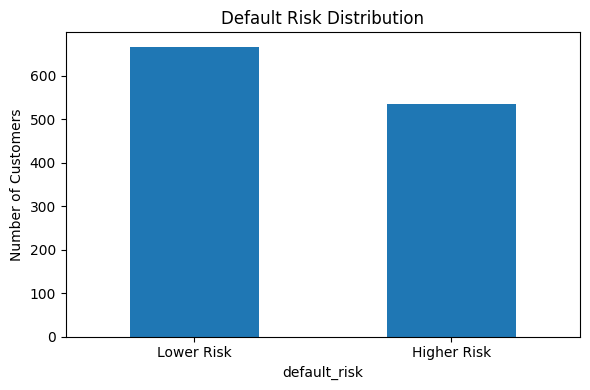

In [23]:
plt.figure(figsize=(6, 4))
df["default_risk"].value_counts().sort_index().plot(kind="bar")
plt.title("Default Risk Distribution")
plt.xlabel("default_risk")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Lower Risk", "Higher Risk"], rotation=0)
plt.tight_layout()
plt.show()


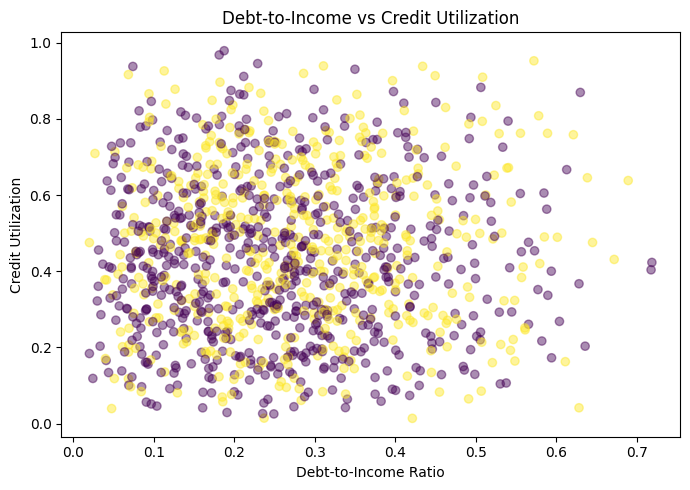

In [24]:
plt.figure(figsize=(7, 5))
plt.scatter(df["debt_to_income"], df["credit_utilization"], c=df["default_risk"], alpha=0.45)
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Credit Utilization")
plt.title("Debt-to-Income vs Credit Utilization")
plt.tight_layout()
plt.show()


<Figure size 700x500 with 0 Axes>

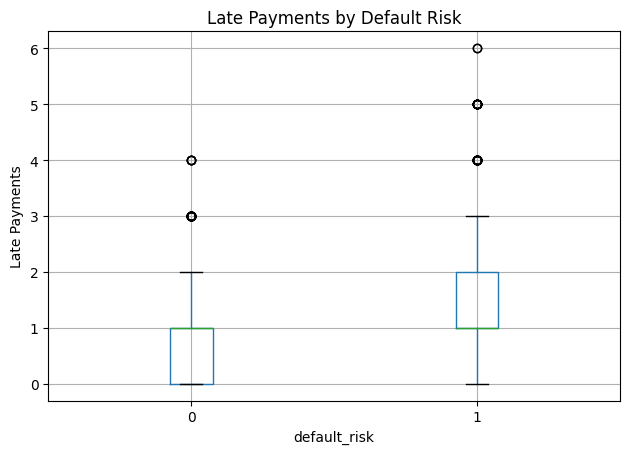

In [25]:
plt.figure(figsize=(7, 5))
df.boxplot(column="late_payments", by="default_risk")
plt.suptitle("")
plt.title("Late Payments by Default Risk")
plt.xlabel("default_risk")
plt.ylabel("Late Payments")
plt.tight_layout()
plt.show()


## 4. Illustrative Credit Score Engine

This is **not a real credit bureau score**. It is a transparent educational formula that converts selected customer attributes into a score from approximately 300–850.

Higher late payments, debt burden, utilization, and loan-to-income ratio reduce the illustrative score, while longer credit history and stronger savings improve it.


In [26]:
def calculate_illustrative_score(row):
    # Normalize selected components into intuitive 0-100 sub-scores.
    late_score = max(0, 100 - min(row["late_payments"], 10) * 10)
    dti_score = max(0, 100 - min(row["debt_to_income"], 1) * 100)
    utilization_score = max(0, 100 - min(row["credit_utilization"], 1) * 100)
    history_score = min(100, row["credit_history_years"] / 20 * 100)
    accounts_score = min(100, row["credit_accounts"] / 10 * 100)
    lti = row["loan_amount"] / max(row["annual_income"], 1)
    lti_score = max(0, 100 - min(lti, 2) / 2 * 100)

    component_score = (
        0.25 * late_score
        + 0.20 * dti_score
        + 0.20 * utilization_score
        + 0.15 * history_score
        + 0.10 * accounts_score
        + 0.10 * lti_score
    )

    return round(300 + component_score * 5.5)

def score_band(score):
    if score >= 750:
        return "Excellent", "Lower Risk"
    elif score >= 700:
        return "Good", "Lower Risk"
    elif score >= 650:
        return "Fair", "Moderate Risk"
    elif score >= 600:
        return "Poor", "Higher Risk"
    return "Very Poor", "Higher Risk"

df["illustrative_score"] = df.apply(calculate_illustrative_score, axis=1)
df[["score_band", "score_risk"]] = df["illustrative_score"].apply(
    lambda x: pd.Series(score_band(x))
)

display(df[[
    "illustrative_score", "score_band", "score_risk",
    "late_payments", "debt_to_income", "credit_utilization"
]].head(10))


,illustrative_score,score_band,score_risk,late_payments,debt_to_income,credit_utilization
0,667,Fair,Moderate Risk,1,0.2993,0.2743
1,678,Fair,Moderate Risk,3,0.1056,0.4436
2,637,Poor,Higher Risk,1,0.2106,0.2688
3,613,Poor,Higher Risk,1,0.3249,0.6441
4,725,Good,Lower Risk,0,0.4309,0.1390
5,625,Poor,Higher Risk,2,0.2449,0.6795
6,662,Fair,Moderate Risk,2,0.0755,0.5409
7,629,Poor,Higher Risk,1,0.3305,0.7435
8,672,Fair,Moderate Risk,1,0.1408,0.6051
9,642,Poor,Higher Risk,1,0.3490,0.3013


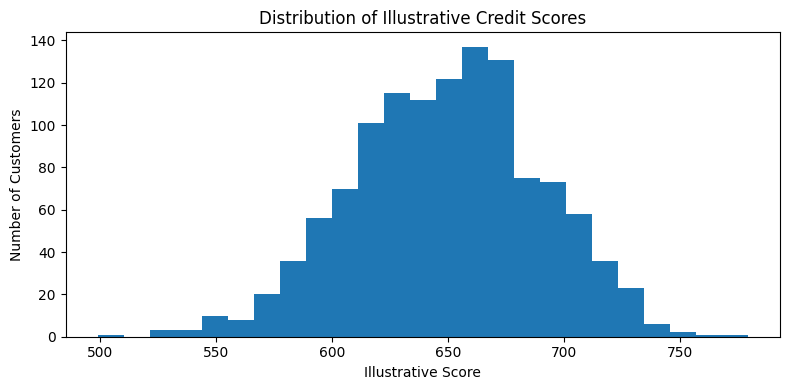

,score_band,score_risk,count,mean,min,max
0,Excellent,Lower Risk,2,771.000000,763,779
1,Fair,Moderate Risk,474,671.004219,650,699
2,Good,Lower Risk,134,714.201493,700,747
3,Poor,Higher Risk,453,627.196468,600,649
4,Very Poor,Higher Risk,137,579.364964,499,599


In [27]:
plt.figure(figsize=(8, 4))
plt.hist(df["illustrative_score"], bins=25)
plt.title("Distribution of Illustrative Credit Scores")
plt.xlabel("Illustrative Score")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

display(
    df.groupby(["score_band", "score_risk"], observed=True)["illustrative_score"]
      .agg(["count", "mean", "min", "max"])
      .reset_index()
)


## 5. Feature Engineering

A useful derived variable is:

**Loan-to-Income Ratio = Loan Amount / Annual Income**

This gives the model a simple representation of loan size relative to customer income.


In [28]:
df["loan_to_income"] = df["loan_amount"] / df["annual_income"]

numeric_features = [
    "age", "annual_income", "employment_years", "loan_amount", "loan_term",
    "credit_history_years", "credit_accounts", "late_payments",
    "debt_to_income", "credit_utilization", "savings_balance",
    "existing_loans", "loan_to_income"
]

categorical_features = [
    "education_level", "employment_type", "home_ownership"
]

target = "default_risk"

X = df[numeric_features + categorical_features].copy()
y = df[target].astype(int)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['age', 'annual_income', 'employment_years', 'loan_amount', 'loan_term', 'credit_history_years', 'credit_accounts', 'late_payments', 'debt_to_income', 'credit_utilization', 'savings_balance', 'existing_loans', 'loan_to_income']
Categorical features: ['education_level', 'employment_type', 'home_ownership']


## 6. Train-Test Split and Preprocessing

The preprocessing pipeline:

1. Splits the data into training and testing sets.
2. Standardizes numerical features.
3. One-hot encodes categorical features.
4. Keeps preprocessing inside a scikit-learn `Pipeline` to avoid data leakage.


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print("Model trained successfully.")


Training rows: 960
Testing rows: 240
Model trained successfully.


## 7. Model Evaluation


In [30]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")


Classification Report:
              precision    recall  f1-score   support

           0      0.707     0.707     0.707       133
           1      0.636     0.636     0.636       107

    accuracy                          0.675       240
   macro avg      0.671     0.671     0.671       240
weighted avg      0.675     0.675     0.675       240

ROC-AUC: 0.755


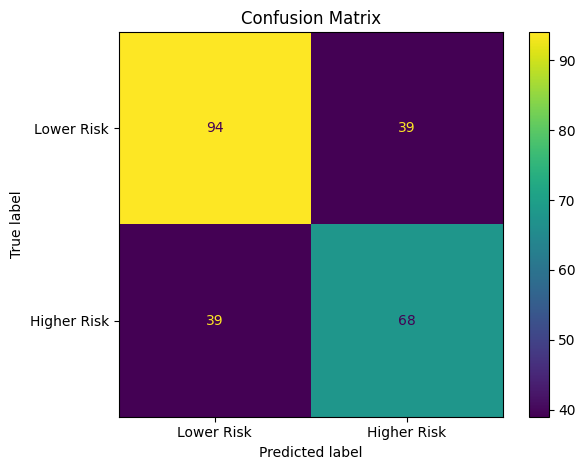

In [31]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lower Risk", "Higher Risk"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


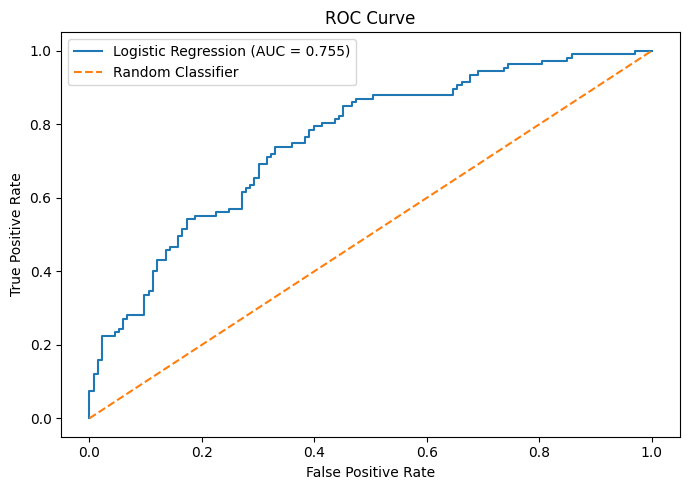

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Explainability: Logistic Regression Coefficients

For Logistic Regression, coefficients indicate the direction of association with the model's predicted probability:

- Positive coefficient → associated with higher predicted default risk.
- Negative coefficient → associated with lower predicted default risk.

These coefficients describe the **model**, not causality. They should not be interpreted as proof that a variable causes default.


In [33]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
}).sort_values("absolute_coefficient", ascending=False)

display(coef_df.head(15))


,feature,coefficient,absolute_coefficient
12,num__loan_to_income,1.186998,1.186998
7,num__late_payments,0.721860,0.721860
9,num__credit_utilization,0.338434,0.338434
8,num__debt_to_income,0.266816,0.266816
6,num__credit_accounts,0.204937,0.204937
5,num__credit_history_years,-0.198125,0.198125
10,num__savings_balance,-0.192547,0.192547
16,cat__employment_type_Contract,0.190955,0.190955
11,num__existing_loans,0.145407,0.145407
14,cat__education_level_High School,0.128576,0.128576


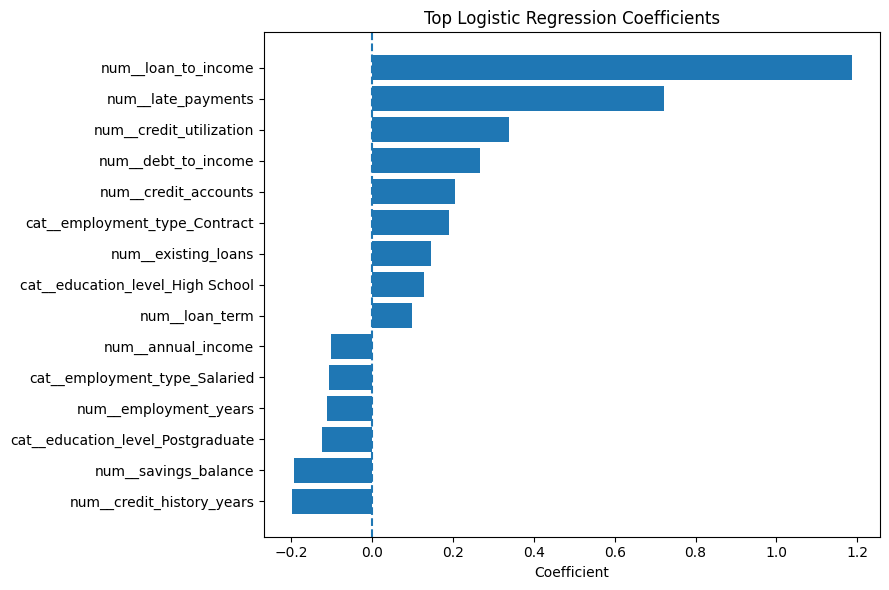

In [34]:
top = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()


## 9. New-Customer Risk Prediction

Enter a hypothetical customer's information below. The model returns:

- Predicted class
- Probability of higher default risk
- Illustrative credit score
- Illustrative score band

The probability is a model output for this synthetic academic dataset and should not be treated as a real-world credit decision.


In [35]:
new_customer = pd.DataFrame([{
    "age": 29,
    "annual_income": 700000,
    "employment_years": 5,
    "loan_amount": 450000,
    "loan_term": 36,
    "credit_history_years": 6,
    "credit_accounts": 5,
    "late_payments": 1,
    "debt_to_income": 0.32,
    "credit_utilization": 0.38,
    "savings_balance": 180000,
    "existing_loans": 1,
    "education_level": "Graduate",
    "employment_type": "Salaried",
    "home_ownership": "Rent"
}])

new_customer["loan_to_income"] = (
    new_customer["loan_amount"] / new_customer["annual_income"]
)

pred_class = int(pipeline.predict(new_customer[numeric_features + categorical_features])[0])
pred_prob = float(pipeline.predict_proba(new_customer[numeric_features + categorical_features])[0, 1])

new_score = calculate_illustrative_score(new_customer.iloc[0])
new_band, new_risk = score_band(new_score)

print("MODEL PREDICTION")
print("----------------")
print(f"Predicted class: {pred_class}")
print(f"Predicted higher-risk probability: {pred_prob:.2%}")

print("\nILLUSTRATIVE SCORE")
print("------------------")
print(f"Score: {new_score}")
print(f"Band: {new_band}")
print(f"Risk label: {new_risk}")


MODEL PREDICTION
----------------
Predicted class: 0
Predicted higher-risk probability: 40.50%

ILLUSTRATIVE SCORE
------------------
Score: 656
Band: Fair
Risk label: Moderate Risk


## 10. Batch Risk Predictions

Generate model probabilities for every customer and inspect the highest predicted-risk cases.

Again, these are outputs from a synthetic academic model—not lending recommendations.


In [36]:
results = df[[
    "illustrative_score", "score_band", "score_risk",
    "default_risk"
]].copy()

results["predicted_default_probability"] = pipeline.predict_proba(
    df[numeric_features + categorical_features]
)[:, 1]

results["predicted_risk_class"] = (
    results["predicted_default_probability"] >= 0.50
).astype(int)

display(
    results.sort_values("predicted_default_probability", ascending=False)
           .head(10)
)


,illustrative_score,score_band,score_risk,default_risk,predicted_default_probability,predicted_risk_class
490,596,Very Poor,Higher Risk,1,0.999777,1
1104,538,Very Poor,Higher Risk,1,0.999670,1
78,549,Very Poor,Higher Risk,1,0.999636,1
1027,582,Very Poor,Higher Risk,1,0.999451,1
680,499,Very Poor,Higher Risk,1,0.999271,1
707,668,Fair,Moderate Risk,1,0.999270,1
117,623,Poor,Higher Risk,1,0.998758,1
430,663,Fair,Moderate Risk,1,0.998528,1
681,590,Very Poor,Higher Risk,1,0.998356,1
712,585,Very Poor,Higher Risk,1,0.998147,1


## 11. Key Learning Outcomes

This notebook demonstrates:

- Credit-risk fundamentals
- Synthetic data generation
- Exploratory Data Analysis
- Feature engineering
- Standardization and categorical encoding
- Logistic Regression classification
- Class balancing
- Probability-based prediction
- Confusion matrix and classification report
- ROC-AUC evaluation
- Basic model explainability
- The distinction between an illustrative score and an ML prediction

### ⚠️ Final Disclaimer

This project is for **academic and educational purposes only**. The dataset is synthetic and the credit-score calculation is illustrative. The model and score should **not** be used for actual lending, credit, financial, or other high-impact decisions.
